# TechLn — анализ рынка вакансий аналитики данных

**Цель:** понять структуру рынка из данных, чтобы помочь с выпусникам российских вузов с трудоустройством в айти, а конректно в анализ данных

**Источник:** 9266 вакансий из 3 Telegram каналов (можно масштаьироваться, просто нужно будет регулярками дорабатывать импорт из тг):
- `role` — 11 канонических категорий
- `grade` + годы опыта
- `salary` — с валютой и gross/net
- `skills` — словарь 120+ технологий

**Структура исследования:**
1. **Этап 1.** Базовый EDA на всём датасете - *что вообще в данных*
2. **Этап 2.** Динамика рынка 2020-2026 - *как менялся рынок*
3. **Этап 3.** Глубокий портрет популярной вакансии  - *типичная вакансия и эволюция требований*

##  общая ячейка для всего notebook, с общим стилем

In [48]:
import json
import warnings
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)

# Палитра проекта
PRIMARY = "#065A82"
ACCENT = "#02C39A"
SECONDARY = "#1C7293"
MUTED = "#94A3B8"

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (11, 5)
plt.rcParams["font.size"] = 10
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

# Глобальный порядок грейдов — используется во многих ячейках
GRADE_ORDER = ["junior", "middle", "senior", "lead"]

---

# Базовый EDA на всём датасете

> Цель: понять что вообще в данных.
> **`other` оставляем** - это бекендерские вакансии с фкн вакансий

### 1.1 Загрузка датасета

In [49]:
# Загрузка обогащённого датасета и базовая подготовка
PROCESSED = Path("../data/processed/vacancies.json")
with open(PROCESSED, "r", encoding="utf-8") as f:
    raw = json.load(f)

df = pd.DataFrame(raw)
df["published_at"] = pd.to_datetime(df["published_at"], errors="coerce", utc=True)
df["year"] = df["published_at"].dt.year
df["month"] = df["published_at"].dt.to_period("M")

print(f"Размер: {df.shape}")
print(f"Период: {df['published_at'].min().date()} — {df['published_at'].max().date()}")
print(f"Колонки: {list(df.columns)}")

Размер: (9266, 27)
Период: 2017-10-07 — 2026-05-26
Колонки: ['source', 'source_id', 'title', 'employer', 'city', 'url', 'salary_from', 'salary_to', 'salary_currency', 'salary_gross', 'employment', 'schedule', 'key_skills', 'skills', 'skills_raw', 'description', 'search_query', 'search_position', 'grade', 'experience_years_from', 'experience_years_to', 'role_canonical', 'published_at', 'parsed_at', 'raw', 'year', 'month']


**Загружено 9266 вакансий за период октябрь 2017 — май 2026**

В DataFrame 27 колонок. Ключевые колонки для анализа:
`role_canonical`, `grade`, `experience_years_from`, `salary_from`, `salary_to`,
`salary_currency`, `skills`, `published_at`.

Прерватили `published_at` в datetime, извлекли `year` и `month` - эт нам понадобится в анализе динамики

### 1.2 Качество данных — заполненность полей

In [50]:
key_fields = [
    "salary_from", "salary_currency", "salary_gross",
    "grade", "experience_years_from",
    "role_canonical", "employer", "city",
    "skills",
]

quality_rows = []
for f in key_fields:
    if f == "skills":
        filled = df[f].apply(lambda x: isinstance(x, list) and len(x) > 0).sum()
    else:
        filled = df[f].notna().sum()
    quality_rows.append({
        "поле": f,
        "заполнено": filled,
        "процент": round(100 * filled / len(df), 1),
    })

quality = pd.DataFrame(quality_rows).sort_values("процент", ascending=False).reset_index(drop=True)
print(quality.to_string(index=False))

# Длина описаний
desc_len = df["description"].dropna().str.len()
print(f"\nДлина описаний — min: {desc_len.min()}, медиана: {int(desc_len.median())}, max: {desc_len.max()}")
print(f"Q1: {int(desc_len.quantile(0.25))}, Q3: {int(desc_len.quantile(0.75))}")

                 поле  заполнено  процент
       role_canonical       9266    100.0
               skills       5564     60.0
                grade       4865     52.5
          salary_from       3122     33.7
      salary_currency       3122     33.7
         salary_gross       2213     23.9
experience_years_from       1763     19.0
             employer          0      0.0
                 city          0      0.0

Длина описаний — min: 300, медиана: 1036, max: 4789
Q1: 522, Q3: 1722


**Качество данных по ключевым полям сильно различается.** Канонический классификатор ролей покрывает все 100% датасета — поле `role_canonical` заполнено всегда, как минимум значением `other`. Чуть хуже обстоят дела с навыками: они извлечены примерно из 60% вакансий, у остальных 40% описания слишком короткие или содержат технологии вне нашего словаря. Грейд явно указан в 53% постов - обычно в заголовке или начале объявления.

С зарплатами и опытом ситуация заметно хуже. Поле `salary_from` заполнено только в 33.7% случаев — многие вакансии скрывают вилку, ограничиваясь формулировкой "по результатам собеседования". Опыт в годах (`experience_years_from`) указан ещё реже, лишь в 19% постов: работодатели чаще пишут грейд, чем количество лет.

Поля `employer` и `city` пустые во всех записях - это **ограничение Telegram-источника**: в свободных текстовых постах редко встречается структурированная информация о компании и локации. На hh.ru эти поля были бы заполнены, но API hh.ru закрылся в апреле 2026, поэтому я переключился на Telegram. Как следствие, географический анализ и анализ работодателей в этом исследовании не будет разобран(

Длина спаршенных описаний - от 300 до 4789 символов с медианой около 1036. Нижняя граница 300 символов — это фильтр в самом парсере: посты короче отсекались как мусорные объявления каналов ("ищем нетворкинг" итд)

### 1.3 Распределение ролей (весь датасет, включая other)

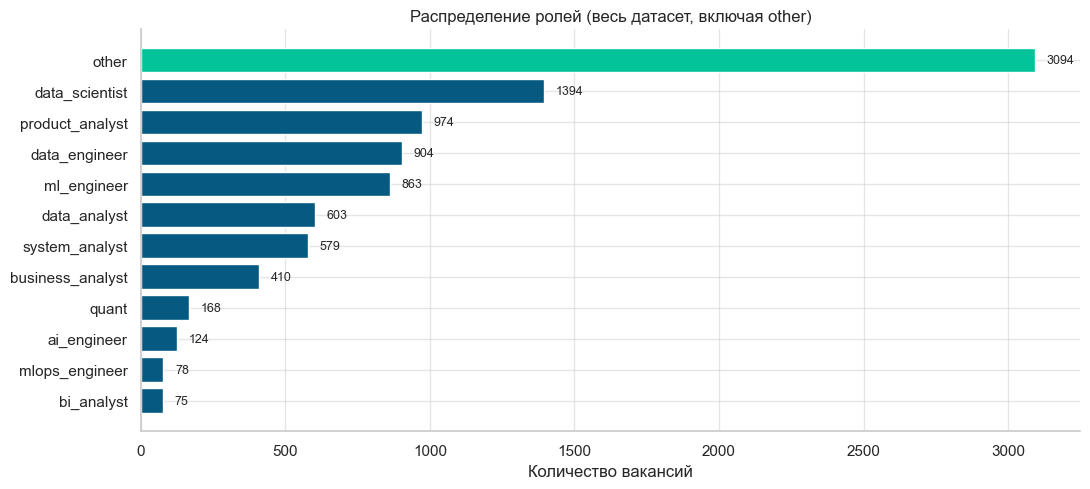

role_canonical
other               3094
data_scientist      1394
product_analyst      974
data_engineer        904
ml_engineer          863
data_analyst         603
system_analyst       579
business_analyst     410
quant                168
ai_engineer          124
mlops_engineer        78
bi_analyst            75
Name: count, dtype: int64


In [51]:
role_counts = df["role_canonical"].value_counts()

fig, ax = plt.subplots(figsize=(11, 5))
colors = [ACCENT if r == "other" else PRIMARY for r in role_counts.index[::-1]]
bars = ax.barh(role_counts.index[::-1], role_counts.values[::-1], color=colors)
ax.set_xlabel("Количество вакансий")
ax.set_title("Распределение ролей (весь датасет, включая other)")

for bar in bars:
    width = bar.get_width()
    ax.text(width + 40, bar.get_y() + bar.get_height()/2,
            f"{int(width)}", va="center", fontsize=9)

plt.tight_layout()
plt.show()
print(role_counts)

**33.4% вакансий - это `other`** (3094 поста). Это не аналитические вакансии, это произошло из-за того что я парсил вакансии с телеграмм канала фкн с вакансиями и там есть вакансии не только по аналитике, но и по другим айтишным специальностям.


**Лидеры аналитического сегмента:**
- `data_scientist` (1394, 15%) - классическая роль DS, она доминирует над всеми другими
- `product_analyst` (974, 10.5%) - растущий сегмент продуктовой аналитики
- `data_engineer` (904, 9.8%) - инфраструктурная аналитика
- `ml_engineer` (863, 9.3%) - инженерия ML моделей

**Хвост:** `bi_analyst` (75) и `mlops_engineer` (78) — нишевые роли, одни биай так как это все таки больше в экономике, чем к айти, а данные все таки айти релейтед. А мль опс просто хай скил вакансия и ее очевидно мало.

Далее в этапах 2-3 `other` убираем - он не интересен для рынка аналитики

### 1.4 Грейды и требуемый опыт

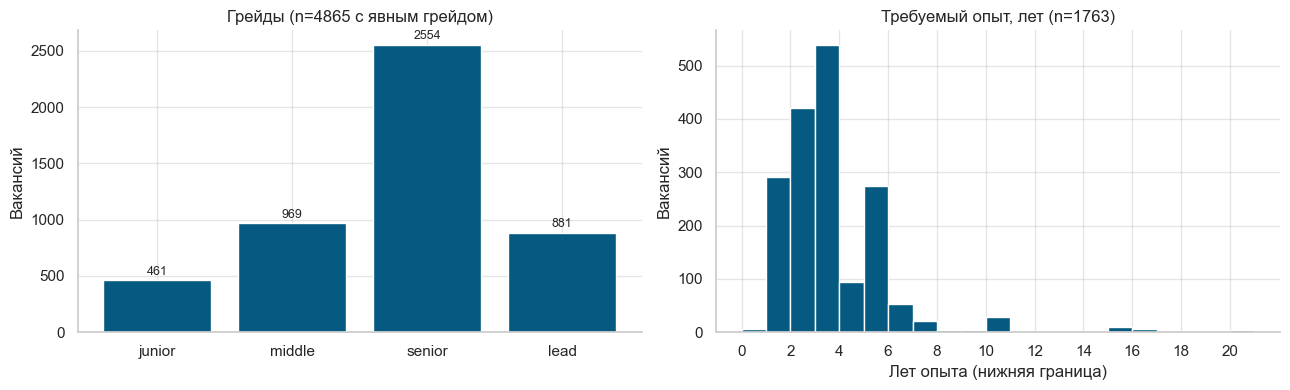


Медианный опыт: 3 лет
75% вакансий требуют не более 4 лет опыта

Грейды:
grade
junior     461
middle     969
senior    2554
lead       881
Name: count, dtype: int64


In [52]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

# Грейды
grade_counts = df["grade"].value_counts()
grade_counts = grade_counts.reindex(GRADE_ORDER).fillna(0).astype(int)

ax1.bar(grade_counts.index, grade_counts.values, color=PRIMARY)
ax1.set_title(f"Грейды (n={grade_counts.sum()} с явным грейдом)")
ax1.set_ylabel("Вакансий")
for i, v in enumerate(grade_counts.values):
    ax1.text(i, v + 50, str(v), ha="center", fontsize=9)

# Опыт в годах
exp = df["experience_years_from"].dropna()
ax2.hist(exp, bins=range(0, int(exp.max()) + 2), color=PRIMARY, edgecolor="white")
ax2.set_title(f"Требуемый опыт, лет (n={len(exp)})")
ax2.set_xlabel("Лет опыта (нижняя граница)")
ax2.set_ylabel("Вакансий")
ax2.set_xticks(range(0, int(exp.max()) + 1, 2))

plt.tight_layout()
plt.show()

print(f"\nМедианный опыт: {exp.median():.0f} лет")
print(f"75% вакансий требуют не более {exp.quantile(0.75):.0f} лет опыта")
print(f"\nГрейды:")
print(grade_counts)

**Грейды (только где он явно указан, n=4865):**
- `senior` — 2554 (52% от тех где указан грейд) - **рынок ищет опытных, сильно больше, их даже искать не надо**
- `middle` — 969 (20%)
- `lead` — 881 (18%)
- `junior` — 461 (9%)

Junior-вакансий **в 5 раз меньше** чем senior ((

**Опыт в годах (n=1763):**
- Медиана: **3 года**
- Самый частый: 3 года (539), 2 года (420), 1 год (291)
- Q3 = 5 лет (75% вакансий требуют не более 5 лет опыта)
- Хвост до 20 лет — единичные lead/architect позиции

### 1.5 Зарплаты — общий портрет

Валюты:
salary_currency
RUR     1956
USD     1017
EUR      112
KZT       17
JPY       12
USDT       8
Name: count, dtype: int64


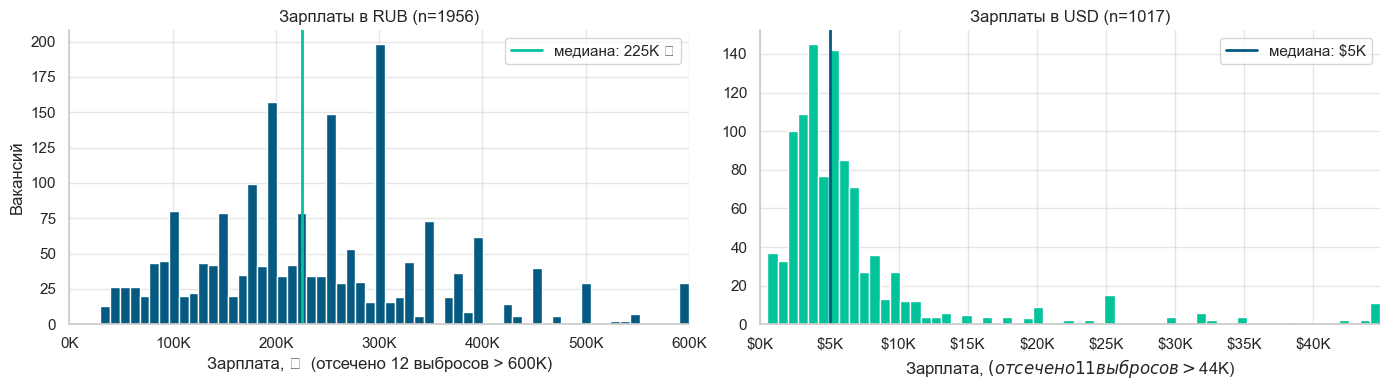


RUB :
count       1956.0
mean      244978.0
std       181184.0
min        30000.0
25%       156875.0
50%       225000.0
75%       300000.0
max      4000000.0
Name: salary_mid, dtype: float64

USD :
count     1017.0
mean      6632.0
std       7274.0
min        500.0
25%       3000.0
50%       5000.0
75%       6500.0
max      50000.0
Name: salary_mid, dtype: float64

RUB Q99 (граница отсечки): 600K ₽
USD Q99 (граница отсечки): $44K


In [64]:
# Зарплаты в двух валютах
df_sal = df[df["salary_from"].notna() & df["salary_currency"].notna()].copy()
df_sal["salary_mid"] = df_sal.apply(
    lambda r: (r["salary_from"] + r["salary_to"]) / 2 if pd.notna(r["salary_to"])
              else r["salary_from"], axis=1,
)

print("Валюты:")
print(df_sal["salary_currency"].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

#RUB
rur = df_sal[df_sal["salary_currency"] == "RUR"]["salary_mid"]
# Отрезаем хвост по 99-му квантилю — топ-1% выбросов уходят за пределы графика
rur_q99 = rur.quantile(0.99)
rur_clipped = rur.clip(upper=rur_q99)
n_clipped_rur = (rur > rur_q99).sum()

axes[0].hist(rur_clipped, bins=60, color=PRIMARY, edgecolor="white")
axes[0].axvline(rur.median(), color=ACCENT, linewidth=2,
                label=f"медиана: {int(rur.median()/1000)}K ₽")
axes[0].set_xlim(0, rur_q99)
axes[0].set_title(f"Зарплаты в RUB (n={len(rur)})")
axes[0].set_xlabel(f"Зарплата, ₽  (отсечено {n_clipped_rur} выбросов > {int(rur_q99/1000)}K)")
axes[0].set_ylabel("Вакансий")
axes[0].legend()
axes[0].xaxis.set_major_formatter(plt.matplotlib.ticker.FuncFormatter(
    lambda x, _: f"{int(x/1000)}K"))

# USD
usd = df_sal[df_sal["salary_currency"] == "USD"]["salary_mid"]
usd_q99 = usd.quantile(0.99)
usd_clipped = usd.clip(upper=usd_q99)
n_clipped_usd = (usd > usd_q99).sum()

axes[1].hist(usd_clipped, bins=60, color=ACCENT, edgecolor="white")
axes[1].axvline(usd.median(), color=PRIMARY, linewidth=2,
                label=f"медиана: ${int(usd.median()/1000)}K")
axes[1].set_xlim(0, usd_q99)
axes[1].set_title(f"Зарплаты в USD (n={len(usd)})")
axes[1].set_xlabel(f"Зарплата, $  (отсечено {n_clipped_usd} выбросов > ${int(usd_q99/1000)}K)")
axes[1].legend()
axes[1].xaxis.set_major_formatter(plt.matplotlib.ticker.FuncFormatter(
    lambda x, _: f"${int(x/1000)}K"))

plt.tight_layout()
plt.show()

print("\nRUB :")
print(rur.describe().round(0))
print("\nUSD :")
print(usd.describe().round(0))
print(f"\nRUB Q99 (граница отсечки): {int(rur_q99/1000)}K ₽")
print(f"USD Q99 (граница отсечки): ${int(usd_q99/1000)}K")

**Зарплата указана у 33% вакансий (3122 из 9266).** Большая часть указывается в рублях (1956 постов, 63% от тех где есть salary) или в долларах (1017, 33%). На остальные валюты приходится менее 5%: евро (112), казахские тенге (17), японские йены (12), USDT (8). Для анализа берём только RUB и USD: это 90% данных и при этом два разных сегмента рынка, которые имеет смысл смотреть отдельно. USD вакансии это релокация, иностранные компании и работа на международные продукты, смешивать их с рублёвой Россией через конвертацию неправильно (курс зависит от даты публикации, и сегменты по природе различные)

**В рублёвом сегменте** медиана составляет 200К, среднее 208К. Основная масса (от Q1 до Q3) лежит в диапазоне 125К - 250К, минимум 30К, максимум 3 миллиона. Чтобы хвост выбросов не сжимал основное распределение в левую часть графика, на гистограмме отсекли верхний 1% (всё что выше Q99). **В долларовом сегменте** медиана $4000, среднее $5763 (среднее выше медианы значит распределение скошено вправо, есть топовые предложения по $30K–$50K). Q1=$3000, Q3=$6000. На USD-графике также отсечён верхний 1%.

То что среднее заметно выше медианы в обеих валютах это типичный признак рынка труда: много вакансий со средней зарплатой и небольшой хвост очень высокооплачиваемых позиций (CTO, лиды команд, senior в иностранных компаниях).


### 1.6 Топ-20 навыков на рынке

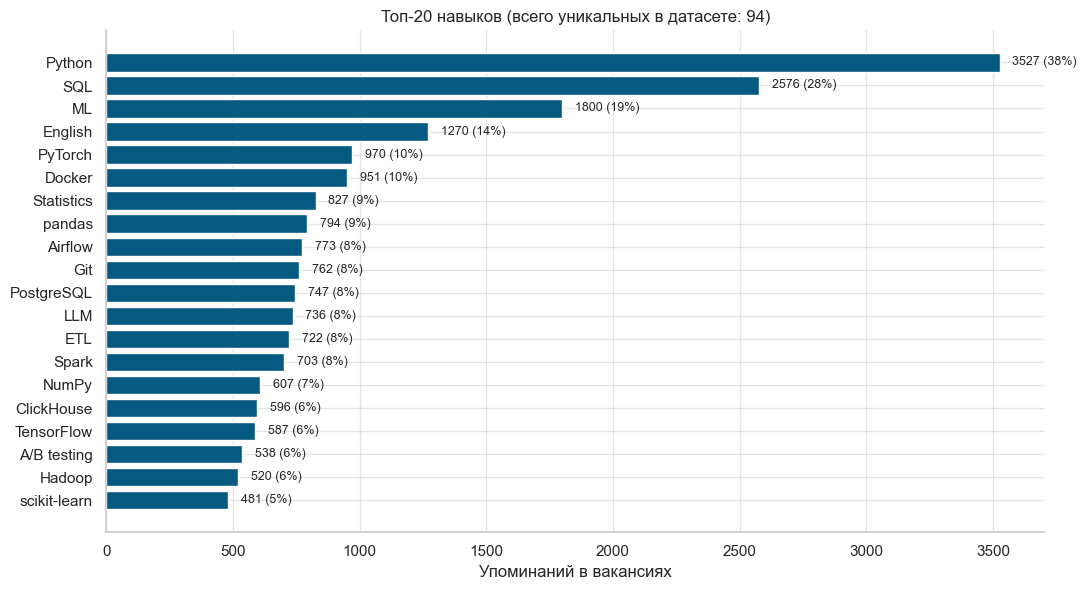


Навыков на вакансию: медиана 2, среднее 3.4, max 24
Вакансий без определённых навыков: 3702 (40%)


In [65]:
# Топ-20 навыков по частоте
skills_flat = [s for sk in df["skills"].dropna() for s in sk]
skill_counts = pd.Series(skills_flat).value_counts().head(20)

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(skill_counts.index[::-1], skill_counts.values[::-1], color=PRIMARY)
ax.set_xlabel("Упоминаний в вакансиях")
ax.set_title(f"Топ-20 навыков (всего уникальных в датасете: {len(set(skills_flat))})")

for bar in bars:
    w = bar.get_width()
    pct = 100 * w / len(df)
    ax.text(w + 50, bar.get_y() + bar.get_height()/2,
            f"{int(w)} ({pct:.0f}%)", va="center", fontsize=9)

plt.tight_layout()
plt.show()

# Кол-во навыков на вакансию
n_skills = df["skills"].apply(lambda x: len(x) if isinstance(x, list) else 0)
print(f"\nНавыков на вакансию: медиана {n_skills.median():.0f}, среднее {n_skills.mean():.1f}, max {n_skills.max()}")
print(f"Вакансий без определённых навыков: {(n_skills == 0).sum()} ({100*(n_skills == 0).mean():.0f}%)")

**Python + SQL = база рынка** - без них почти ничего нет в аналитике
**English (1270 вакансий)** - английский упоминается чаще чем большинство технологий, ну я думаю это базовое умение просто

**Кол-во навыков на вакансию:**
- Медиана 2, среднее 3.4
- 40% вакансий (3702) — без распознанных навыков (короткие описания, тестовый формат, или необычные технологии не из словаря)

**Это нормально для словаря:** мы покрываем 60% постов с разумной точностью.
Можно было б ллм парсер настроить, но это уже в другой раз

---

#  Динамика рынка во времени

> Цель: понять как менялся рынок аналитики 2020-2026, поэтому избавлемся от other

### 2.1 Объём аналитических вакансий по годам

Аналитический срез (без other): 6134 вакансий


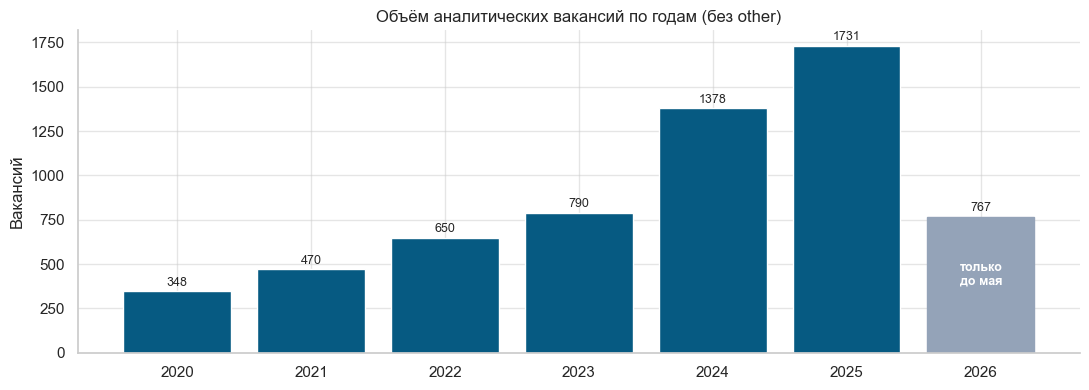


Объём по годам:
year
2020     348
2021     470
2022     650
2023     790
2024    1378
2025    1731
2026     767
Name: count, dtype: int64

Годовой прирост:
  2021: 348 -> 470  (+35%)
  2022: 470 -> 650  (+38%)
  2023: 650 -> 790  (+22%)
  2024: 790 -> 1378  (+74%)
  2025: 1378 -> 1731  (+26%)
  2026: 1731 -> 767  (-56%)


In [67]:
# Отфильтровываем other и неполные годы.
# 2017-2019 — слишком мало (2+24+110), исключаем чтобы не искажать.
# 2026 - частичный год (только до мая), отметим визуально.

df_analytics = df[df["role_canonical"] != "other"].copy()
df_a = df_analytics[df_analytics["year"].between(2020, 2026)].copy()

print(f"Аналитический срез (без other): {len(df_a)} вакансий")

# Объём вакансий по годам
by_year = df_a["year"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(11, 4))
bars = ax.bar(by_year.index.astype(str), by_year.values, color=PRIMARY)
# 2026 - серым (неполный год)
if 2026 in by_year.index:
    bars[-1].set_color(MUTED)
ax.set_title("Объём аналитических вакансий по годам (без other)")
ax.set_ylabel("Вакансий")

for bar, val in zip(bars, by_year.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 30,
            str(val), ha="center", fontsize=9)

if 2026 in by_year.index:
    ax.text(len(by_year) - 1, by_year.values[-1] / 2,
            "только\nдо мая", ha="center", color="white",
            fontsize=9, fontweight="bold")

plt.tight_layout()
plt.show()

print("\nОбъём по годам:")
print(by_year)

# Темпы роста год к году
print("\nГодовой прирост:")
for i in range(1, len(by_year)):
    prev = by_year.iloc[i-1]
    curr = by_year.iloc[i]
    pct = 100 * (curr - prev) / prev if prev else 0
    print(f"  {by_year.index[i]}: {prev} -> {curr}  ({pct:+.0f}%)")

**Качественный скачок в 2024 году** — рынок аналитики данных вырос на 70% за год.
Это совпадает с **массовым внедрением LLM**  компании начали
активно искать ML/AI специалистов.

2026 идёт темпом 2025 — рынок остаётся горячим.

### 2.2 Динамика ролей по годам

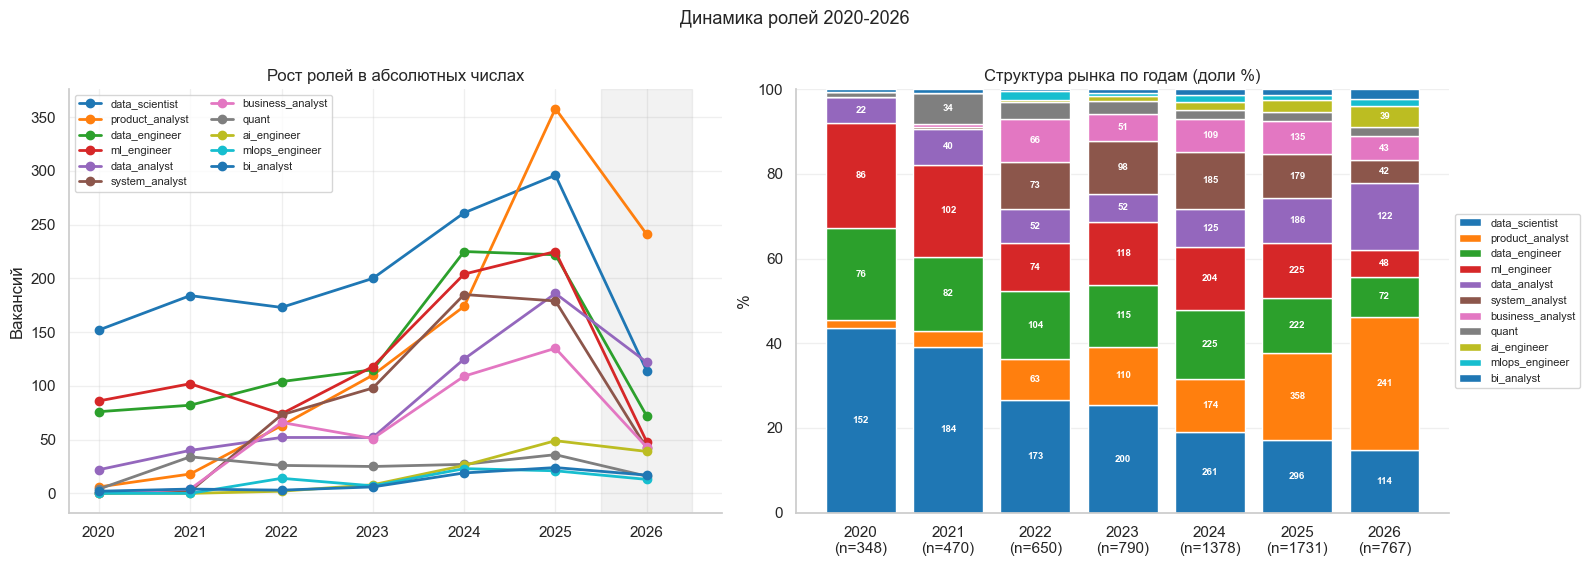


Годовой прирост каждой роли (2024 -> 2025):
  data_scientist      : 261 -> 296  (+13%)
  product_analyst     : 174 -> 358  (+106%)
  data_engineer       : 225 -> 222  (-1%)
  ml_engineer         : 204 -> 225  (+10%)
  data_analyst        : 125 -> 186  (+49%)
  system_analyst      : 185 -> 179  (-3%)


In [70]:
# Стэк столбиков по годам, доли ролей + line plot роста
pivot_year = pd.crosstab(df_a["year"], df_a["role_canonical"])
order = pivot_year.sum(axis=0).sort_values(ascending=False).index
pivot_year = pivot_year[order]
pivot_pct = pivot_year.div(pivot_year.sum(axis=1), axis=0) * 100

roles = pivot_year.columns.tolist()
palette = sns.color_palette("tab10", n_colors=len(roles))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5.5))

# Левый - line plot, абсолютный рост
for i, role in enumerate(roles):
    ax1.plot(pivot_year.index, pivot_year[role], marker="o", linewidth=2,
             label=role, color=palette[i])
ax1.set_title("Рост ролей в абсолютных числах")
ax1.set_ylabel("Вакансий")
ax1.legend(loc="upper left", fontsize=8, ncol=2)
ax1.grid(alpha=0.3)
ax1.axvspan(2025.5, 2026.5, alpha=0.1, color="gray")

# Правый barplot с процентами
bottom = np.zeros(len(pivot_pct))
x_labels = [f"{y}\n(n={pivot_year.loc[y].sum()})" for y in pivot_pct.index]
for i, role in enumerate(roles):
    bars = ax2.bar(x_labels, pivot_pct[role], bottom=bottom, label=role, color=palette[i])
    for j, (bar, pct) in enumerate(zip(bars, pivot_pct[role])):
        if pct >= 5:
            abs_val = pivot_year[role].iloc[j]
            ax2.text(bar.get_x() + bar.get_width()/2, bottom[j] + pct/2,
                     str(int(abs_val)), ha="center", va="center",
                     fontsize=7, color="white", fontweight="bold")
    bottom += pivot_pct[role].values

ax2.set_title("Структура рынка по годам (доли %)")
ax2.set_ylabel("%")
ax2.set_ylim(0, 100)
ax2.legend(loc="center left", bbox_to_anchor=(1, 0.5), fontsize=8)
ax2.grid(alpha=0.3, axis="y")

plt.suptitle("Динамика ролей 2020-2026", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print("\nГодовой прирост каждой роли (2024 -> 2025):")
for role in roles[:6]:
    if 2024 in pivot_year.index and 2025 in pivot_year.index:
        v24 = pivot_year.loc[2024, role]
        v25 = pivot_year.loc[2025, role]
        if v24 > 0:
            print(f"  {role:20s}: {v24} -> {v25}  ({100*(v25-v24)/v24:+.0f}%)")

**Видим несколько историй:**

**1. Data Scientist - стабильный лидер.** Удерживает 22-25% доли все годы,
растёт вместе с рынком, но не быстрее него. Это **устоявшаяся профессия**.

**2. Product Analyst и Data Engineer - догоняющие.**
В 2020 их было меньше, в 2024-2025 они стали почти равны DS по объёму.
Особенно заметен рост product_analyst - это эра продуктовых команд.

**3. AI Engineer и MLOps - хайп.**
В 2020-2022 их в датасете нет вообще или единицы. Появляются
заметной долей с 2024. Это **новые роли, рождённые эпохой LLM**.

**4. Quant — нишевый стабильный сегмент.** 1-2% во все годы.

Гипотеза «DS растёт быстрее других» — **не подтверждается**.
Лидеры по темпу роста — `ai_engineer`/`mlops_engineer` (от 0 до +-3% за 3 года).
DS растёт по рынку рынка, самая стабильная вакансия.

### 2.3 Динамика навыков и LLM

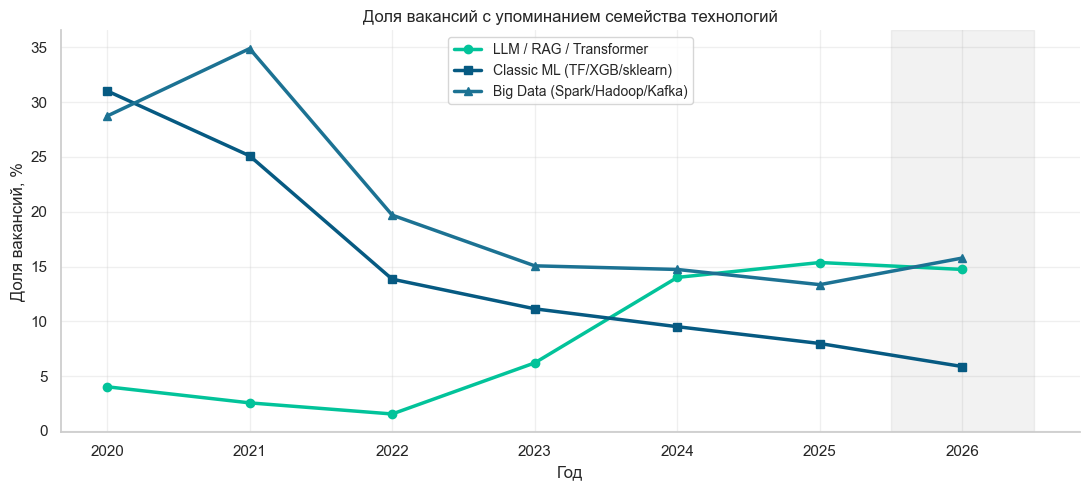

LLM-навыки по годам:
  2020: 4.0%
  2021: 2.6%
  2022: 1.5%
  2023: 6.2%
  2024: 14.0%
  2025: 15.4%
  2026: 14.7%

Classic ML по годам:
  2020: 31.0%
  2021: 25.1%
  2022: 13.8%
  2023: 11.1%
  2024: 9.5%
  2025: 8.0%
  2026: 5.9%


In [73]:
# Сравниваем три семейства технологий: LLM (новые), Classic ML, Big Data
LLM_FAMILY = {"LLM", "RAG", "LangChain", "OpenAI", "Claude", "HuggingFace",
              "Transformer", "Llama", "Mistral", "Gemini", "vLLM", "LangGraph"}
CLASSIC_ML = {"scikit-learn", "TensorFlow", "XGBoost", "LightGBM", "CatBoost"}
BIG_DATA = {"Spark", "Hadoop", "Kafka", "ClickHouse"}


def skill_share_by_year(df_sub, skills_set):
    out = {}
    for year, g in df_sub.groupby("year"):
        total = len(g)
        has = g["skills"].apply(
            lambda lst: bool(set(lst) & skills_set) if isinstance(lst, list) else False
        ).sum()
        out[year] = 100 * has / total if total else 0
    return out


llm = skill_share_by_year(df_a, LLM_FAMILY)
classic = skill_share_by_year(df_a, CLASSIC_ML)
bigdata = skill_share_by_year(df_a, BIG_DATA)

fig, ax = plt.subplots(figsize=(11, 5))
years_x = sorted(llm.keys())
ax.plot(years_x, [llm[y] for y in years_x], marker="o", linewidth=2.5,
        label="LLM / RAG / Transformer", color=ACCENT)
ax.plot(years_x, [classic[y] for y in years_x], marker="s", linewidth=2.5,
        label="Classic ML (TF/XGB/sklearn)", color=PRIMARY)
ax.plot(years_x, [bigdata[y] for y in years_x], marker="^", linewidth=2.5,
        label="Big Data (Spark/Hadoop/Kafka)", color=SECONDARY)

ax.set_title("Доля вакансий с упоминанием семейства технологий")
ax.set_ylabel("Доля вакансий, %")
ax.set_xlabel("Год")
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
ax.axvspan(2025.5, 2026.5, alpha=0.1, color="gray")

plt.tight_layout()
plt.show()

print("LLM-навыки по годам:")
for y in years_x:
    print(f"  {y}: {llm[y]:.1f}%")

print("\nClassic ML по годам:")
for y in years_x:
    print(f"  {y}: {classic[y]:.1f}%")

**Самый яркий тренд исследования - рост LLM-навыков.**

**До 2022:** упоминания LLM были редкостью (+-2%).

**2023-2024:** рост в 8 раз за 2 года.
**2025:** **каждая шестая аналитическая вакансия упоминает LLM/RAG/Transformer**.

Это **самая яркая динамика на рынке аналитики за последние 5 лет**.
Совпадает с релизами ChatGPT (ноябрь 2022), Claude (2023)

**Classic ML** держит 20-28% - не падает, но и не растёт. Это базовый стек, без него никуда.
**Big Data (Spark/Kafka)** остаётся стабильно 15-20% - инфраструктура не уходит.

**Вывод для рекомендаций:** апликантом нужно учить LLM-стек обязательно к 2026, при этом
не забывать классические алгоритмы и базовую инженерию данных, но опять таки, нужно делать скидку на то, что LLM сейчас, это как знание английского

# Глубокий портрет выбранной роли

> Цель: для выбранной роли создать портрет вакансии в 2025-2026 и показать эволюцию требований.

### 3.0 Выбор роли для глубокого анализа

In [74]:
# roles `data_scientist`, `product_analyst`, `data_engineer`,
# `ml_engineer`, `data_analyst`, `system_analyst`, `business_analyst`,
# `quant`, `ai_engineer`, `mlops_engineer`, `bi_analyst`.
FOCUS_ROLE = "data_scientist"

df_focus = df_a[df_a["role_canonical"] == FOCUS_ROLE].copy()
print(f"Вакансия для глубокого анализа: {FOCUS_ROLE}")
print(f"Вакансий за 2020-2026: {len(df_focus)}")
print(f"\nРаспределение по годам:")
print(df_focus["year"].value_counts().sort_index())

Роль для глубокого анализа: data_scientist
Вакансий за 2020-2026: 1380

Распределение по годам:
year
2020    152
2021    184
2022    173
2023    200
2024    261
2025    296
2026    114
Name: count, dtype: int64


### 3.1 Зарплаты в выбранной Вакансии (RUB + USD раздельно)

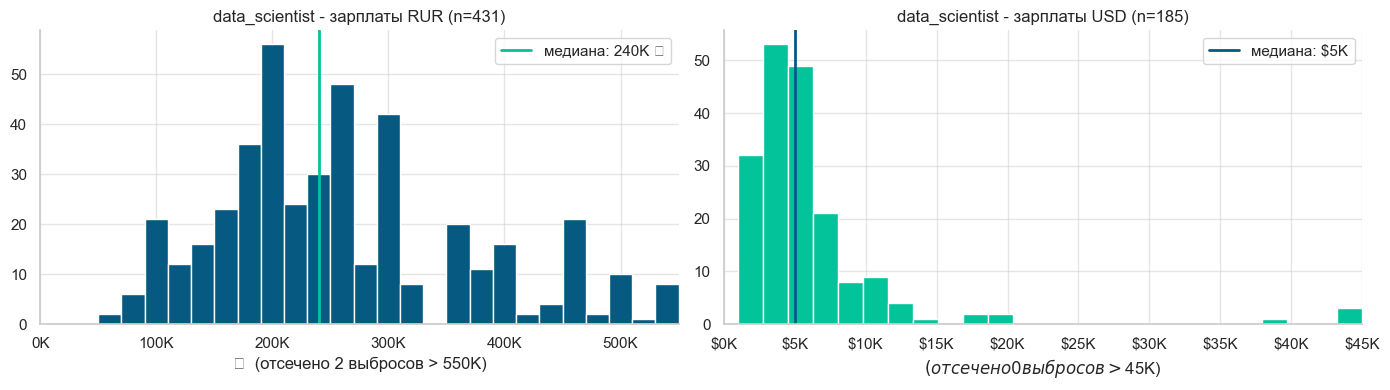


Зарплаты data_scientist по грейдам:

  RUR:
          median  count
grade                  
junior  110000.0     16
middle  200000.0     69
senior  275000.0    153
lead    300000.0     46

  USD:
        median  count
grade                
junior  4000.0      2
middle  2000.0     13
senior  5000.0     80
lead    7500.0     10


In [79]:
df_focus_sal = df_focus[df_focus["salary_from"].notna() & df_focus["salary_currency"].notna()].copy()
df_focus_sal["salary_mid"] = df_focus_sal.apply(
    lambda r: (r["salary_from"] + r["salary_to"]) / 2 if pd.notna(r["salary_to"])
              else r["salary_from"], axis=1,
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

rur = df_focus_sal[df_focus_sal["salary_currency"] == "RUR"]["salary_mid"]
usd = df_focus_sal[df_focus_sal["salary_currency"] == "USD"]["salary_mid"]

# RUB
if len(rur) > 5:
    rur_q99 = rur.quantile(0.99)
    rur_clipped = rur.clip(upper=rur_q99)
    n_clipped_rur = (rur > rur_q99).sum()

    axes[0].hist(rur_clipped, bins=25, color=PRIMARY, edgecolor="white")
    axes[0].axvline(rur.median(), color=ACCENT, linewidth=2,
                    label=f"медиана: {int(rur.median()/1000)}K ₽")
    axes[0].set_xlim(0, rur_q99)
    axes[0].set_title(f"{FOCUS_ROLE} - зарплаты RUR (n={len(rur)})")
    axes[0].set_xlabel(f"₽  (отсечено {n_clipped_rur} выбросов > {int(rur_q99/1000)}K)")
    axes[0].legend()
    axes[0].xaxis.set_major_formatter(plt.matplotlib.ticker.FuncFormatter(
        lambda x, _: f"{int(x/1000)}K"))
else:
    axes[0].text(0.5, 0.5, "Слишком мало\nRUR-вакансий", ha="center",
                 transform=axes[0].transAxes, fontsize=12)
    axes[0].set_title(f"{FOCUS_ROLE} - RUR (n={len(rur)})")

# USD
if len(usd) > 5:
    usd_q99 = usd.quantile(0.99)
    usd_clipped = usd.clip(upper=usd_q99)
    n_clipped_usd = (usd > usd_q99).sum()

    axes[1].hist(usd_clipped, bins=25, color=ACCENT, edgecolor="white")
    axes[1].axvline(usd.median(), color=PRIMARY, linewidth=2,
                    label=f"медиана: ${int(usd.median()/1000)}K")
    axes[1].set_xlim(0, usd_q99)
    axes[1].set_title(f"{FOCUS_ROLE} - зарплаты USD (n={len(usd)})")
    axes[1].set_xlabel(f"$  (отсечено {n_clipped_usd} выбросов > ${int(usd_q99/1000)}K)")
    axes[1].legend()
    axes[1].xaxis.set_major_formatter(plt.matplotlib.ticker.FuncFormatter(
        lambda x, _: f"${int(x/1000)}K"))
else:
    axes[1].text(0.5, 0.5, "Слишком мало\nUSD-вакансий", ha="center",
                 transform=axes[1].transAxes, fontsize=12)
    axes[1].set_title(f"{FOCUS_ROLE} - USD (n={len(usd)})")

plt.tight_layout()
plt.show()

# Числовая сводка по грейдам
print(f"\nЗарплаты {FOCUS_ROLE} по грейдам:")
for currency in ["RUR", "USD"]:
    sub = df_focus_sal[df_focus_sal["salary_currency"] == currency]
    if len(sub) < 5:
        continue
    print(f"\n  {currency}:")
    summary = sub.groupby("grade")["salary_mid"].agg(["median", "count"]).round(0)
    summary = summary.reindex(GRADE_ORDER).dropna(how="all")
    print(summary.to_string())

### 3.2 Грейды и опыт в выбранной вакансии

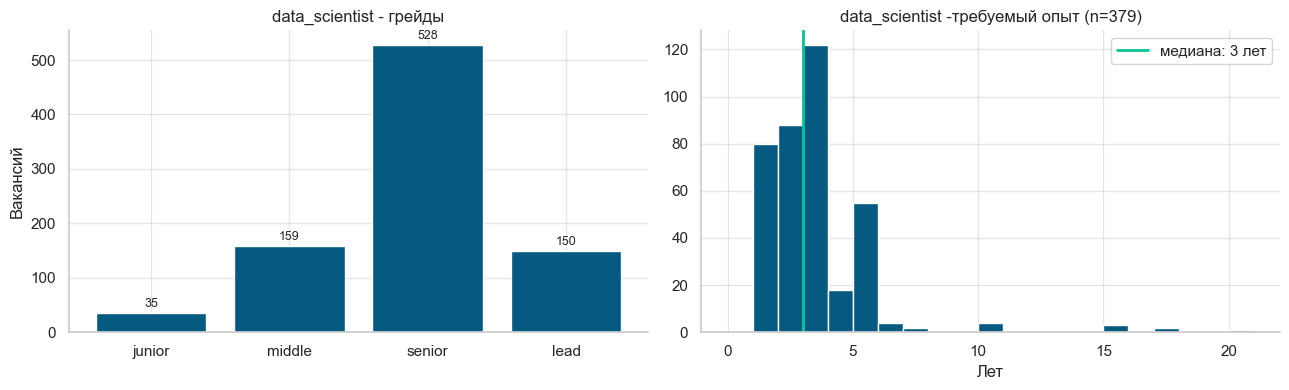


Грейды data_scientist:
grade
junior     35
middle    159
senior    528
lead      150
Name: count, dtype: int64

Опыт (n=379):  медиана 3, Q3 3 лет


In [81]:
# Распределение грейдов и опыта внутри выбранной вакансии
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

gr = df_focus["grade"].value_counts().reindex(GRADE_ORDER).fillna(0).astype(int)
axes[0].bar(gr.index, gr.values, color=PRIMARY)
axes[0].set_title(f"{FOCUS_ROLE} - грейды")
axes[0].set_ylabel("Вакансий")
for i, v in enumerate(gr.values):
    axes[0].text(i, v + max(gr.values) * 0.02, str(v), ha="center", fontsize=9)

exp_focus = df_focus["experience_years_from"].dropna()
if len(exp_focus) > 0:
    axes[1].hist(exp_focus, bins=range(0, int(exp_focus.max()) + 2),
                 color=PRIMARY, edgecolor="white")
    axes[1].set_title(f"{FOCUS_ROLE} -требуемый опыт (n={len(exp_focus)})")
    axes[1].set_xlabel("Лет")
    axes[1].axvline(exp_focus.median(), color=ACCENT, linewidth=2,
                    label=f"медиана: {int(exp_focus.median())} лет")
    axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\nГрейды {FOCUS_ROLE}:")
print(gr)
if len(exp_focus) > 0:
    print(f"\nОпыт (n={len(exp_focus)}):  медиана {exp_focus.median():.0f}, Q3 {exp_focus.quantile(0.75):.0f} лет")

Видно что джунов прям очень мало, мне кажется что это в целом тенденция профессий с большим порогом входа


### 3.3 Топ навыков

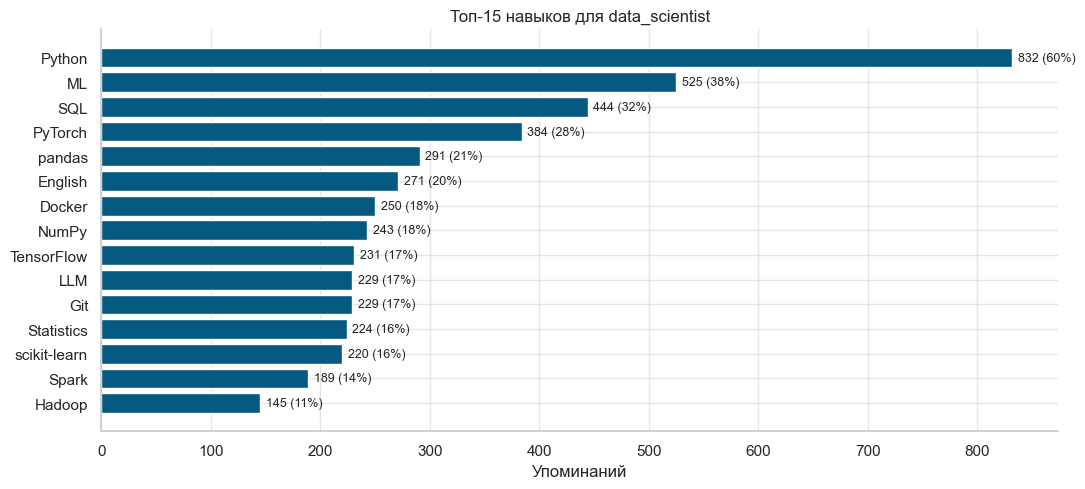


Топ-15 навыков для data_scientist:
Python          832
ML              525
SQL             444
PyTorch         384
pandas          291
English         271
Docker          250
NumPy           243
TensorFlow      231
LLM             229
Git             229
Statistics      224
scikit-learn    220
Spark           189
Hadoop          145
Name: count, dtype: int64


In [61]:
focus_skills = [s for sk in df_focus["skills"].dropna() for s in sk]
focus_top = pd.Series(focus_skills).value_counts().head(15)

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.barh(focus_top.index[::-1], focus_top.values[::-1], color=PRIMARY)
ax.set_title(f"Топ-15 навыков для {FOCUS_ROLE}")
ax.set_xlabel("Упоминаний")

total_focus = len(df_focus)
for bar in bars:
    w = bar.get_width()
    pct = 100 * w / total_focus
    ax.text(w + 5, bar.get_y() + bar.get_height()/2,
            f"{int(w)} ({pct:.0f}%)", va="center", fontsize=9)

plt.tight_layout()
plt.show()

print(f"\nТоп-15 навыков для {FOCUS_ROLE}:")
print(focus_top)

### 3.4 Эволюция навыков

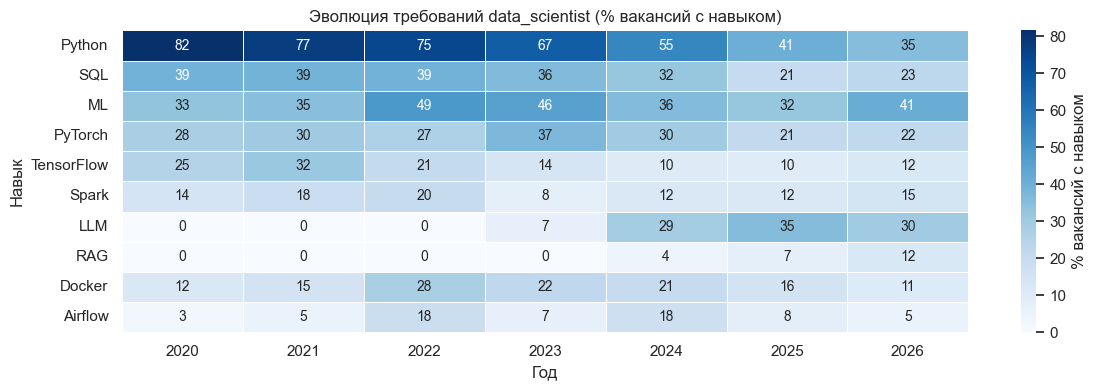


Таблица:
skill  Python   SQL    ML  PyTorch  TensorFlow  Spark   LLM   RAG  Docker  Airflow
year                                                                              
2020     81.6  39.5  32.9     27.6        25.0   14.5   0.0   0.0    11.8      2.6
2021     77.2  39.1  34.8     30.4        31.5   18.5   0.0   0.0    15.2      5.4
2022     74.6  39.3  48.6     26.6        20.8   20.2   0.0   0.0    27.7     18.5
2023     67.0  36.5  45.5     37.0        14.0    7.5   7.0   0.0    22.0      7.0
2024     54.8  32.2  36.0     29.9        10.3   11.9  29.1   4.2    20.7     17.6
2025     40.5  20.6  32.1     21.3        10.1   11.8  35.5   7.4    15.5      8.1
2026     35.1  22.8  41.2     21.9        12.3   14.9  29.8  12.3    10.5      5.3


In [82]:
# Как менялись требования к {FOCUS_ROLE} по годам
TRACKED = ["Python", "SQL", "ML", "PyTorch", "TensorFlow", "Spark",
           "LLM", "RAG", "Docker", "Airflow"]

rows = []
for year, g in df_focus.groupby("year"):
    total = len(g)
    if total < 10:  # отсекаем годы с малым объёмом
        continue
    for skill in TRACKED:
        has = g["skills"].apply(
            lambda lst: skill in lst if isinstance(lst, list) else False
        ).sum()
        rows.append({"year": year, "skill": skill, "pct": 100 * has / total})

if rows:
    evol = pd.DataFrame(rows).pivot(index="year", columns="skill", values="pct")[TRACKED]

    fig, ax = plt.subplots(figsize=(12, 4))
    sns.heatmap(evol.T, annot=True, fmt=".0f", cmap="Blues",
                cbar_kws={"label": "% вакансий с навыком"},
                linewidths=0.5, linecolor="white", ax=ax)
    ax.set_title(f"Эволюция требований {FOCUS_ROLE} (% вакансий с навыком)")
    ax.set_xlabel("Год")
    ax.set_ylabel("Навык")

    plt.tight_layout()
    plt.show()

    print("\nТаблица:")
    print(evol.round(1))
else:
    print("Слишком мало вакансий в выбранной роли для эволюции по годам.")

### 3.5 Портрет  вакансии в текущее время

In [86]:
# Карточка "типичная вакансия в 2025-2026"
df_recent = df_focus[df_focus["year"].between(2025, 2026)].copy()

sal_recent = df_recent[df_recent["salary_currency"] == "RUR"]
sal_med_rur = sal_recent["salary_from"].median() if len(sal_recent) > 5 else None

exp_med = df_recent["experience_years_from"].median()
top_grade = df_recent["grade"].value_counts().idxmax() if df_recent["grade"].notna().any() else None

skills_recent = [s for sk in df_recent["skills"].dropna() for s in sk]
top_skills = pd.Series(skills_recent).value_counts().head(7)

# Простая карточка без рамок (рендерится одинаково во всех терминалах)

print(f"  ПОРТРЕТ {FOCUS_ROLE.upper()} В 2025-2026")

print(f"  Объём:           {len(df_recent)} вакансий за период")
print(f"  Грейд:           {top_grade or 'не определён'} (самый частый)")
if not pd.isna(exp_med):
    print(f"  Опыт:            от {int(exp_med)} лет (медиана)")
else:
    print(f"  Опыт:            мало данных")
if sal_med_rur:
    print(f"  Зарплата (RUR):  ~{int(sal_med_rur/1000)}К ₽ (медиана)")
else:
    print(f"  Зарплата (RUR):  мало данных")
print()
print(f"  Топ-7 навыков:")
for skill, count in top_skills.items():
    pct = 100 * count / len(df_recent)
    print(f"    - {skill:20s}  ({pct:.0f}% вакансий)")

  ПОРТРЕТ DATA_SCIENTIST В 2025-2026
  Объём:           410 вакансий за период
  Грейд:           senior (самый частый)
  Опыт:            от 3 лет (медиана)
  Зарплата (RUR):  ~250К ₽ (медиана)

  Топ-7 навыков:
    - Python                (39% вакансий)
    - ML                    (35% вакансий)
    - LLM                   (34% вакансий)
    - PyTorch               (21% вакансий)
    - SQL                   (21% вакансий)
    - English               (17% вакансий)
    - pandas                (15% вакансий)


## Итоги исследования

**1 Этап: общий анализ**
9266 вакансий, 11 ролей, 33% other-шум, 60% покрытие навыками,
`employer` и `city` отсутствуют из-за источника (Telegram).

**2 Этап: динамика рынка 2020-2026:**
- Рост x4 за 5 лет
- 2024 — год качественного скачка (+70%)
- `data_scientist` стабилен, `ai_engineer`/`mlops_engineer` - новая волна
- **LLM-навыки выросли с 2.5% до 17% за 5 лет** - главный технологический сдвиг

**3) глубокий анализ вакансии**

**Я решил проанализирвоать позицию DS, как самую стабильную и получил такую карточку**,
 ПОРТРЕТ DATA_SCIENTIST В 2025-2026
  Объём:           410 вакансий за период
  Грейд:           senior (самый частый)
  Опыт:            от 3 лет (медиана)
  Зарплата (RUR):  ~250К ₽ (медиана)

  Топ-7 навыков:
    - Python                (39% вакансий)
    - ML                    (35% вакансий)
    - LLM                   (34% вакансий)
    - PyTorch               (21% вакансий)
    - SQL                   (21% вакансий)
    - English               (17% вакансий)
